# ASTRO 501 — HW3b Interferometry Data Analysis

In this HW, you will be carrying out a binary fit using archival optical interferometry data and comparing to the published results using the PMOIRED python library.  

As for last assignment, you can either turn in your pdf of your completed notebook (on GradeScope) or just the figures/text requested as indicated by **P1** , **P2**, etc.

## Due March 31, 2026.


# ASTRO 501 — Binary fitting of HD 174881 with PMOIRED

**Goal:** Download the calibrated **L3 science-ready OIFITS** dataset for **HD 174881** from the **JMMC OIDB**, then use **PMOIRED** to perform a **binary fit** on the **UT 2007 Jul 07 MIRC** data. Finally, compare your fitted separation and position angle against the values reported in **Torres et al. (2024)**.

You can use chatgpt to help you, though it may not know this library especially well without guidance.


## What you will do
1. Install `pmoired`.
2. Download the correct OIFITS dataset from OIDB.
3. Load the OIFITS file with `PMOIRED`.
4. Follow PMOIRED example 3 binary tutorial. Note you will need to somewhat modify the example to fit for the uniform-disk diameters of both the primary and secondary.
5. Compare with the literature values from Torres et al. (2024).

## What you will turn in
P1. Show uv coverage, V2 and closure phases

P2. Show significance map of binary grid search

P3. Show V2 and closure phase data along with best fit model results

P4. Show model image of binary stars with comparison to Torres et al. (figure1)

P5. Show comparison of your model fit parameters to Torres et al. (table 3)


## External resources
- OIDB: https://www-static-2019.jmmc.fr/oidb.htm
- PMOIRED repo: https://github.com/amerand/PMOIRED
- PMOIRED examples repo: https://github.com/amerand/PMOIRED_examples
- Torres et al. (2024): https://ui.adsabs.harvard.edu/abs/2024ApJ...977...43T/abstract


## 0. Directory setup and manual download workflow

I recommend a directory structure like this:

```text
HW3b/
  HW3b_starter.ipynb
  data/
    HD174881/
      <put the UT2007Jul07 L3 MIRC OIFITS file here>
```

### OIDB search instructions
Go to the OIDB search page and do the following:

1. Search target: **HD 174881**
2. Instrument: **MIRC**
3. Data level: **L3 (science ready)**
4. Select the dataset for **UT 2007 Jul 07**
5. Download the OIFITS product
6. Place the downloaded `.fits` / `.oifits` file(s) in:

```text
data/HD174881/
```




In [3]:

# If needed, install PMOIRED.
# Uncomment ONE of the options below.

%pip install pmoired
#%pip install git+https://github.com/amerand/PMOIRED

# After installation, restart the kernel if Jupyter asks you to.


Note: you may need to restart the kernel to use updated packages.


## Following PMOIRED Example 3:  AX Cir and companion search
https://htmlpreview.github.io/?https://github.com/amerand/PMOIRED_examples/blob/main/html/EX3%20companion%20search%20AXCir.html

Only in our case, you will use the oifits data for HD174881 you downloaded in the earlier step. 

In the cells below, I give an example of the plot or table you need to create for the assignment. Your plot doesn't have to look identical but should contain the same basic information.

## P1. Show uv coverage, V2 and closure phases

Using the built-in PMOIRED plotting utilities, show the uv coverage,vis2, and closure phases in the HD174881 data file.  This is just data not fits done yet.  Here is an example:

<img src="figs/oifits_data.jpg" width="500">



loadOI: loading data/HD174881/MIRC.2007Jul07.HR_7112.v1.oifits
  > insname: "H_PRISM" targname: "HR_7112" pipeline: ""
  > MJD: (2,) [54288.2518..54288.2688] ~2007-07-07T06:14:51.523
  > E1-S1-W1-W2 | WL: (8,) [ 1.527 .. 1.768 ] um (R~48 P~48) {'T3': 4, 'VIS': 6, 'VIS2': 6} | TELL: False 


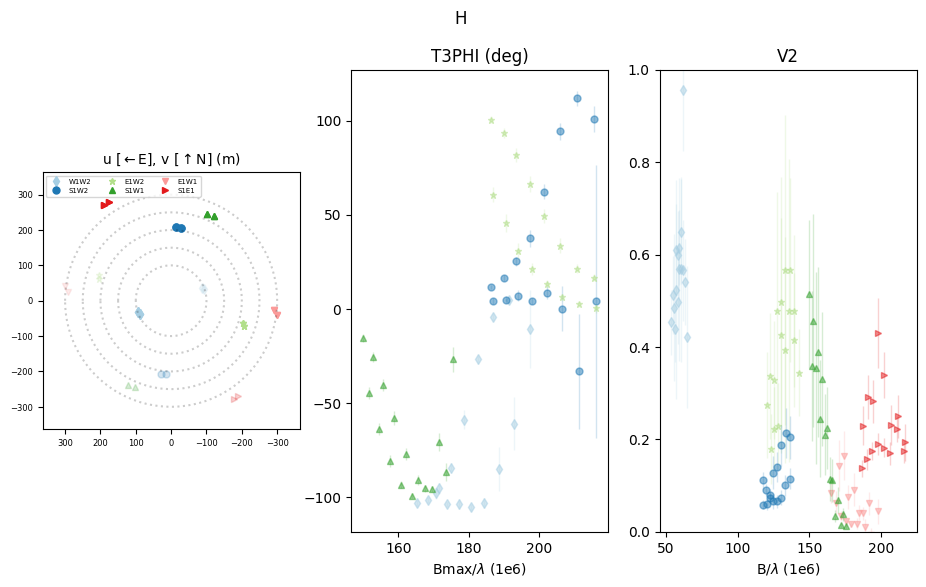

In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
import astropy.io.fits as fits
import pmoired

oi = pmoired.OI("data/HD174881/MIRC.2007Jul07.HR_7112.v1.oifits")
print(oi)
oi.show(obs=['T3PHI','V2'])

## P2. Show significance map of binary grid search

After following the fitting procedures in the example, include your gridsearch result showing binary detection signficance map. Should show a clear detection of the companion similar (but not identical) to below:

<img src="figs/significance_map.jpg" width="500">


step: 1.0mas, range: +- 22.7mas
588 grid points not within constraints
Mon Mar 30 11:47:19 2026: running 1716 fits on 16 processes
Mon Mar 30 11:47:50 2026: [████████████████████████████████████████████████████████████]1716/1716   0s   left

Mon Mar 30 11:47:50 2026: it took 30.9s, 0.02s per fit on average [3331.7 fit/minute]
fits to be taken into account: 953 / 1716
  450 did not numerically converge (incl 450 have no uncertainties)
  313 have uncertainties larger than the grid's step[s]
Mon Mar 30 11:47:50 2026: making list of unique minima...
unique minima: 587 / 953 [~1.6 first guesses / minima]
  WARNING!: too many unique minima -> grid too coarse / Nfits too small?  finding the global minimum may be unreliable
Mon Mar 30 11:47:54 2026: linking unique minima to first guess(es)
Mon Mar 30 11:47:54 2026: done
------------
best fit: chi2= 19.178593433005243
{'*,ud':0.710, # +/- 0.045
'c,f': 1.180, # +/- 0.049
'c,x': 1.9700, # +/- 0.0075
'c,y': -2.3128, # +/- 0.0079
'*,f': 1,
'c,ud':0

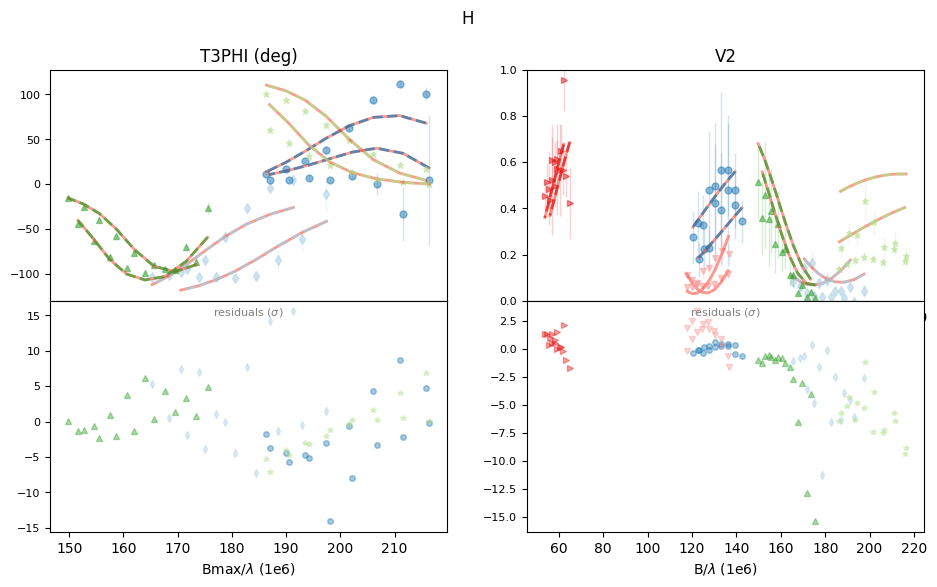

In [4]:
# -- smallest lambda/B in mas (first data set) 
step = 180 * 3600 * 1000e-6 / np.pi / max([np.max(oi.data[0]['OI_VIS2'][k]['B/wl']) for k in oi.data[0]['OI_VIS2']])
R = np.mean(oi.data[0]['WL'] / oi.data[0]['dWL'])
print('step: %.1fmas, range: +- %.1fmas'%(step, R/2*step))
# manual overwrite of step and limits
lim_outer = 10
lim_inner = 0.5

expl = {'grid':{'c,x':(-R/2*step, R/2*step, step), 'c,y':(-R/2*step, R/2*step, step)}}

# -- initial model dict: 'c,x' and 'c,y' do not matter, as they will be explored in the fit
param = {'*,ud':0.8, '*,f':1, 'c,f':0.01, 'c,x':0, 'c,y':0, 'c,ud':0.0}

oi.setupFit({'obs': ['T3PHI','V2']})

do_not_fit = ['A,f']

# -- actual grid fit
oi.gridFit(expl, model=param, doNotFit=['*,f', 'c,ud'], prior=[('c,f', '<', 1)], 
           constrain=[('np.sqrt(c,x**2+c,y**2)', '<=', R*step/2),
                      ('np.sqrt(c,x**2+c,y**2)', '>', step/2) ])

model = oi.bestfit['best'].copy()

oi.show(
    model='best',
    spectro=False,
    showUV=False,
    perSetup=True,
    imFov=None,
    imMax=0.05,
)

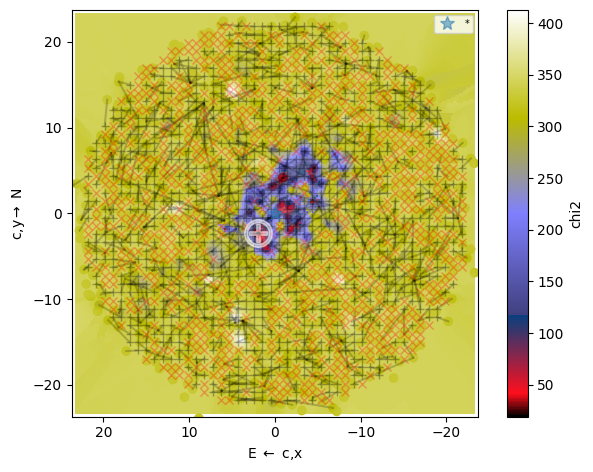

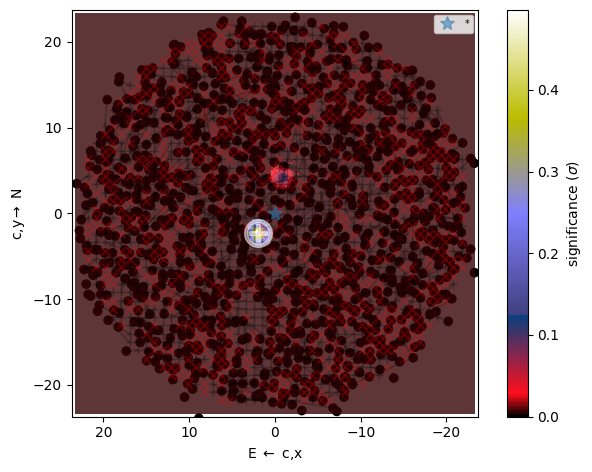

In [6]:
# -- show the 2D grid of reduced chi2
oi.showGrid(interpolate=True, tight=True)
bestUD = oi.bestfit['best']
oi.showGrid(interpolate=True, tight=True, significance=bestUD)

## P3. Show V2 and closure phase data along with best fit model results

After finding the best fit, show the results compared to the data. Should look similar to this:

<img src="figs/binary_results.jpg" width="500">



## P4. Show model image of binary stars with comparison to Torres et al. (figure1)

Compare the model image (two uniform disks) to the paper model image. For this part, you will need to deviate from the example and fit for both the primary and secondary uniform disk sizes.  Should look similar to below:

<img src="figs/pmoired_image.jpg" width="500">
<img src="figs/binary_paper.jpg" width="500">



## P5. Show comparison of your model fit parameters to Torres et al. (table 3)

Lastly, compare your results (with error bars) to the published parameters. There is a oifits bootstrap method that provides error analysis.  For full credit, you should find a way to include the primary and secondary uniform disk sizes along with the flux ratio and separation. For instance, here are some useful parameer keywords.


    "*,ud": 1.0,   # starting guess for primary uniform-disk diameter [mas]
    "*,f": 1.0,    # fixed reference flux [Always keep fixed as its a reference]
    "c,f": 0.3,    # initial flux ratio scale guess
    "c,x": 0.0,    # starting east offset [mas]
    "c,y": 0.0,    # starting north offset [mas]
    "c,ud": 0.0,   # companion uniform disk diameter [mas]

"* = star"
"c = companion"


Here is my comparison table as an example. You can use (delta RA, delta DEC) instead of (separation, PA) if you find it easier.

<img src="figs/comparison.jpg" width="500">

